# 生成 AI ごっこ（解答編)

理解しないくせに答えちゃう AI のなかみ教えます

## AI はなぜわかったふりをして答えちゃうの?

AI って便利ですね。でも内容が正しいかを確かめるしくみはまだまだです。AI に知らないことを説明してもらったり、考えるきっかけをもらって、自分で確かめながら付き合っていきましょう。

## 元データ

名詞と形容詞しかない単語帳

* りんごは丸い
* のりまきは丸い
* りんごは赤い
* 赤いりんごはおいしい
* のりまきはおいしい
* りんごが赤いし丸い

## 前処理

### 形態素解析

1. 名詞とそれ以外に分ける
2. 簡単のため形容詞原形にする



In [1]:
情報 = [
    ["りんご", "丸い"],
    ["のりまき", "丸い"],
    ["りんご", "赤い"],
    ["赤い", "りんご", "おいしい"],
    ["のりまき", "おいしい"],
    ["りんご", "赤い", "丸い"]
    ## 一番最後の文章の形態素の結果を予測して入れてみよう
]

#### (問題)

上のセルで、形態素解析が実行された状態を完成させよう。

##### (発展) 
"バナナは黄色い" を新たな情報として入れるとしたら?

## 次に出る単語の計算

* りんごとのりまきにはどんな形容詞が関係しているのかをコンピュータに覚えさせる。
* 次に出やすい単語を数える。

#### ポイント

このしくみの組み合わせは、
ある単語の次に出る候補の回数を数え上げることができる

In [2]:
次の単語 = {} # 単語に対して次が何回出るかを登録する準備

for 文 in 情報: # 情報から一つずつ文を読む
    for i in range(len(文) - 1):  # "次" を知るために、調べる単語は文の 1 つ前まで
        単語 = 文[i]               # i 番目の文の単語を単語に入れる
        右どなり = 文[i + 1]       # 右どなりの単語を入れる

        if 単語 not in 次の単語:   # ”単語"が初めての単語だったら
            次の単語[単語] = {}         # "次の単語" に登録する準備をする

        if 右どなり not in 次の単語[単語]:  # "右どなり"が初めての単語だったら
            次の単語[単語][右どなり] = 0             # 0を入れて数を数える準備をする

        次の単語[単語][右どなり] += 1   # 次の単語と右どなりの組み合わせに 1 を足す

print(次の単語) # 登録した結果を出す

{'りんご': {'丸い': 1, '赤い': 2, 'おいしい': 1}, 'のりまき': {'丸い': 1, 'おいしい': 1}, '赤い': {'りんご': 1, '丸い': 1}}


#### 次に出る単語の計算に使った文の解説

##### `len()`

リストの数を数える

`len(文)`: 文章の数

In [3]:
len(文)

3

##### `range()`

0 から、その数だけ数字を並べる

`range(len(文)-1)`: 文の形態素の数から 1 つだけ減らして数字を並べる

`range(0, 2)`: 0 から 1 まで 2 個の数字を並べる $$[0, 1]$$


In [4]:
range(len(文)-1) 

range(0, 2)

`文[0]` は `情報`の先頭

In [5]:
文

['りんご', '赤い', '丸い']

In [6]:
文[0]

'りんご'

##### `for` 文

ぐるぐる回る

```
for i in 範囲:
    すること
```

`for` 文と `range()` を組み合わせて、情報全部を読み出して調べることができる。

#### `in` と `not in`

`in`: 含まれているとき

`not in`: 含まれていないとき

### 出現確率を調べる

(復習) "次の単語" に入ってたものを呼んでみて単語として何が出やすいかを見直す

In [7]:
次の単語

{'りんご': {'丸い': 1, '赤い': 2, 'おいしい': 1},
 'のりまき': {'丸い': 1, 'おいしい': 1},
 '赤い': {'りんご': 1, '丸い': 1}}

##### 単語の出現確率を求めるしくみ

りんごの次に出てくる単語は、何回いくつ出てきたか
`次の単語["りんご"]`


In [8]:
次の単語["りんご"]

{'丸い': 1, '赤い': 2, 'おいしい': 1}

1. 全部を足して、合計を求める
2. それぞれの単語の出現回数を合計で割る

In [9]:
りんごの次 = 次の単語["りんご"]

合計 = sum(りんごの次.values())

print("赤い:", りんごの次["赤い"] / 合計) 
print("丸い:", りんごの次["丸い"] / 合計)
print("おいしい:", りんごの次["おいしい"] / 合計)


赤い: 0.5
丸い: 0.25
おいしい: 0.25


#### 辞書形での `values()`

`{これ:いくつ}`　の組み合わせの "いくつ" を並べる。

`{これ:3, あれ:4, それ:5}` なら `[3, 4, 5]`


In [10]:
{"これ": 3, "あれ": 4, "それ" :5}.values()

dict_values([3, 4, 5])

#### sum()

`[3, 4, 5]` 全部足す。

`dict_values([3, 4, 5])` なら `12`

In [11]:
sum([3, 4, 5])

12

#### (練習)

好きな数を入れて実行を押して、足されているか調べよう。

In [12]:
sum([])   # 数字, 数字, ... の組み合わせにする

0

「りんご」に対しては「赤い」が多く出現するはず

### (練習) のりまき

必要な単語を入れて実行してみよう

## 生成確率

のりまきは、1 回ずつなので、どちらが出るかは自由

### ランダムのしくみ

In [13]:
# じゃんけん

import random 

候補 = ["グー", "チョキ", "パー"]

print(random.choice(候補))

パー


### (練習) 

何度かじゃんけんを実行して結果が違うことを確かめよう

### のりまきの文章

In [14]:
import random

食べ物 = "のりまき"

候補 = 次の単語["のりまき"]

print(候補)

説明 = random.choice(
    list(候補)
)

print(食べ物)
print("は")
print(説明)

{'丸い': 1, 'おいしい': 1}
のりまき
は
丸い


### 問題

"食べ物" が "説明" とするにはどこを変えたらいい?: 

(答え)

```
print(食べ物)
print("が")
print(説明)
```

### りんごの文章

In [15]:
食べ物 = "りんご"

候補 = 次の単語["りんご"]

説明 = random.choices(
    
    list(候補),
    weights = list(候補.values()) # 出現確率別に出すオプションを付加
    
)[0]

print(食べ物)
print("は")
print(説明)

りんご
は
おいしい


### (練習)

何度か実行して違う説明が出ることを確かめよう。

## 可視化

重みが違うことを回数で調べる

In [16]:
## Google Colaboratory 日本語を表示するための設定

import sys
import matplotlib.pyplot as plt

if 'google.colab' in sys.modules:
    # Colab環境の場合: バックグラウンドで japanize-matplotlib をインストールして適用
    import subprocess
    subprocess.run(['pip', 'install', 'japanize-matplotlib'])
    import japanize_matplotlib
else:
    # ローカル環境（Macなど）の場合: 指定のフォントを使用
    plt.rcParams["font.family"] = "Hiragino Sans"

{'おいしい': 230, '赤い': 536, '丸い': 234}


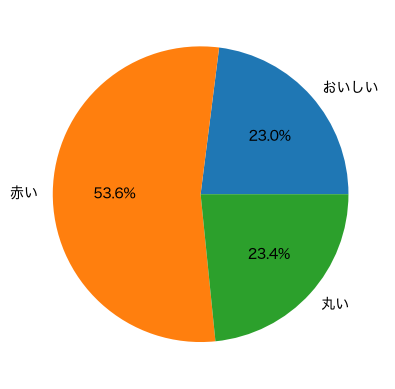

In [17]:
import random
import matplotlib.pyplot as plt

食べ物 = "りんご"
候補 = 次の単語[食べ物]

結果 = {}

for i in range(1000):
    説明 = random.choices(
        list(候補),
        weights=list(候補.values())
    )[0]

    if 説明 not in 結果:
        結果[説明] = 0

    結果[説明] += 1

print(結果)

plt.pie(
    結果.values(),
    labels=結果.keys(),
    autopct="%5.1f%%" # 全体の文字数 5 文字分, 小数値を1桁だけ
)

plt.show()

### (練習) 

何度か実行して、出現割合が少し違うことを確かめよう。

### (練習)

1. (文字列を代入) もう一つの食べ物を表す文字列を入れてみよう

2. (グラフの表示の変更) `autopct` をいろいろ変えたら何が変化するか観察しよう